In [ ]:
import urllib.request
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler

import cloudpickle

In [81]:

# Remove the filter to get actual data
url = 'https://opendata.muenchen.de/api/3/action/datastore_search?resource_id=40094bd6-f82d-4979-949b-26c8dc00b9a7&limit=100'

# Fetch and parse the JSON data
with urllib.request.urlopen(url) as response:
    data = response.read()
    parsed = json.loads(data)


In [82]:
# Extract the records (tabular data)
records = parsed['result']['records']

# Convert to DataFrame
data = pd.DataFrame(records)

In [120]:
data.to_csv('data.csv', index=False)

In [84]:
max=data['JAHR'].max()
min=data['JAHR'].max()

In [85]:
min


np.int64(2024)

In [86]:
max

np.int64(2024)

In [87]:
data.columns

Index(['_id', 'MONATSZAHL', 'AUSPRAEGUNG', 'JAHR', 'MONAT', 'WERT',
       'VORJAHRESWERT', 'VERAEND_VORMONAT_PROZENT',
       'VERAEND_VORJAHRESMONAT_PROZENT', 'ZWOELF_MONATE_MITTELWERT'],
      dtype='object')

In [88]:

data = data[data['JAHR'] <= 2020]


In [89]:
filtered_data = data[['MONATSZAHL', 'AUSPRAEGUNG', 'JAHR', 'MONAT', 'WERT']]

# Optionally rename for clarity
filtered_data = filtered_data.rename(columns={
    'MONATSZAHL': 'Category',
    'AUSPRAEGUNG': 'Accident_Type',
    'JAHR': 'Year',
    'MONAT': 'Month',
    'WERT': 'Value'
})

In [90]:
filtered_data.isna().sum()

Category         0
Accident_Type    0
Year             0
Month            0
Value            0
dtype: int64

In [91]:
filtered_data

,Category,Accident_Type,Year,Month,Value
50,Alkoholunfälle,insgesamt,2020,Summe,430.0
51,Alkoholunfälle,insgesamt,2020,202001,28.0
52,Alkoholunfälle,insgesamt,2020,202002,40.0
53,Alkoholunfälle,insgesamt,2020,202003,27.0
54,Alkoholunfälle,insgesamt,2020,202004,26.0
55,Alkoholunfälle,insgesamt,2020,202005,40.0
56,Alkoholunfälle,insgesamt,2020,202006,49.0
57,Alkoholunfälle,insgesamt,2020,202007,58.0
58,Alkoholunfälle,insgesamt,2020,202008,46.0
59,Alkoholunfälle,insgesamt,2020,202009,46.0


In [92]:
filtered_data['Value'].min()

np.float64(13.0)

In [93]:
filtered_data['Category'].unique()

array(['Alkoholunfälle'], dtype=object)

In [94]:
filtered_data['Accident_Type'].unique()

array(['insgesamt'], dtype=object)

In [95]:
filtered_data['Month'].unique()

array(['Summe', '202001', '202002', '202003', '202004', '202005',
       '202006', '202007', '202008', '202009', '202010', '202011',
       '202012', '201901', '201902', '201903', '201904', '201905',
       '201906', '201907', '201908', '201909', '201910', '201911',
       '201912', '201801', '201802', '201803', '201804', '201805',
       '201806', '201807', '201808', '201809', '201810', '201811',
       '201812', '201701', '201702', '201703', '201704', '201705',
       '201706', '201707', '201708', '201709', '201710'], dtype=object)

In [96]:
filtered_data['Month'].dtype

dtype('O')

In [97]:
filtered_data['Year'].unique()

array([2020, 2019, 2018, 2017])

In [98]:
filtered_data_without_summe = filtered_data[filtered_data['Month'] != 'Summe']
collection = filtered_data_without_summe.groupby(['Year', 'Category'])['Value'].sum().reset_index()# Excluding 'Summe' rows
monthly_data = filtered_data_without_summe[filtered_data_without_summe['Month'] != 'Summe']

# Grouping by Year & Category (e.g., Unfalltype)
computed_sums = monthly_data.groupby(['Year', 'Category'])['Value'].sum().reset_index()

# Also geting the official Summe rows
summe_rows = filtered_data[filtered_data['Month'] == 'Summe'][['Year', 'Category', 'Value']].rename(columns={'Value': 'Reported_Sum'})

# Merging to compare
comparison = pd.merge(computed_sums, summe_rows, on=['Year', 'Category'], how='left')

# Adding a difference column
comparison['Difference'] = comparison['Value'] - comparison['Reported_Sum']


In [99]:
comparison

,Year,Category,Value,Reported_Sum,Difference
0,2017,Alkoholunfälle,334.0,409.0,-75.0
1,2018,Alkoholunfälle,398.0,398.0,0.0
2,2019,Alkoholunfälle,434.0,434.0,0.0
3,2020,Alkoholunfälle,430.0,430.0,0.0


In [100]:
filtered_data[(filtered_data['Year'] == 2017) & (filtered_data['Month'] != 'Summe')]['Month'].unique()
# november and december are not in the data thats why the total is not same as summe

array(['201701', '201702', '201703', '201704', '201705', '201706',
       '201707', '201708', '201709', '201710'], dtype=object)

In [101]:
min=collection['Year'].min()
max=collection['Year'].max()

In [102]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

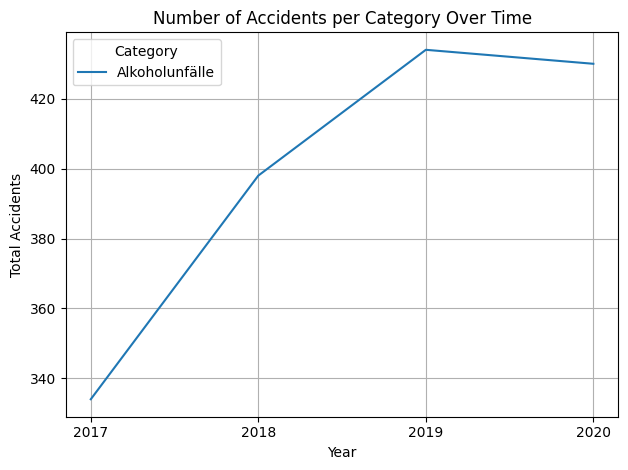

In [103]:
sns.lineplot(data=computed_sums, x='Year', y='Value', hue='Category')
plt.title('Number of Accidents per Category Over Time')
plt.ylabel('Total Accidents')
plt.grid(True)
plt.tight_layout()
plt.xticks(ticks=range(min,max + 1))
plt.show()

In [104]:
model_data=filtered_data_without_summe.copy()

In [105]:
model_data['Year_from_Month'] = model_data['Month'].str[:4].astype(int)
model_data['Month_Numeric'] = model_data['Month'].str[4:6].astype(int)

In [106]:
model_data[['Month', 'Year_from_Month', 'Month_Numeric']].head(10)

,Month,Year_from_Month,Month_Numeric
51,202001,2020,1
52,202002,2020,2
53,202003,2020,3
54,202004,2020,4
55,202005,2020,5
56,202006,2020,6
57,202007,2020,7
58,202008,2020,8
59,202009,2020,9
60,202010,2020,10


In [ ]:
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
model_data['Value_Normalized'] = min_max_scaler.fit_transform(model_data[['Value']])

In [ ]:
X = model_data[['Year', 'Month_Numeric']]
y = model_data['Value_Normalized']

In [112]:
X.shape

(46, 3)

In [113]:
y.shape

(46,)

In [114]:
X.to_csv('X.csv', index=False)

In [115]:
y.to_csv('Y.csv', index=False)

In [116]:
model_data_encoded

,Accident_Type,Year,Month,Value,Year_from_Month,Month_Numeric,cat_Alkoholunfälle,Value_Normalized
51,insgesamt,2020,202001,28.0,2020,1,1,-0.333333
52,insgesamt,2020,202002,40.0,2020,2,1,0.200000
53,insgesamt,2020,202003,27.0,2020,3,1,-0.377778
54,insgesamt,2020,202004,26.0,2020,4,1,-0.422222
55,insgesamt,2020,202005,40.0,2020,5,1,0.200000
56,insgesamt,2020,202006,49.0,2020,6,1,0.600000
57,insgesamt,2020,202007,58.0,2020,7,1,1.000000
58,insgesamt,2020,202008,46.0,2020,8,1,0.466667
59,insgesamt,2020,202009,46.0,2020,9,1,0.466667
60,insgesamt,2020,202010,34.0,2020,10,1,-0.066667


In [ ]:

with open('min_max_scaler3.pkl', 'wb') as f:
    cloudpickle.dump(min_max_scaler, f)
